# COMP6012 Large Language Models and Applications
## Assignment 2: Evaluation of LLM Models for Text Classification and Text Generation
### Adelaide University, 2026

---

**Tasks:**

- Task 1: Text Classification on the Yelp Review Full Dataset using BERT and RoBERTa
- Task 2: Text Summarisation on the CNN/DailyMail Dataset using T5-small and BART-large-cnn


---
## Section 1: Environment Setup
### 1.1 Install Required Libraries

The following libraries are required to run this notebook:

- transformers: Provides pretrained LLM models including BERT, RoBERTa, T5, and BART
- datasets: Used to load benchmark datasets from HuggingFace including Yelp and CNN/DailyMail
- evaluate: Used to compute evaluation metrics such as ROUGE and BLEU
- rouge_score: Backend dependency required for ROUGE metric computation
- scikit-learn: Used to compute classification metrics including accuracy, precision, recall, and F1
- accelerate: Enables GPU-accelerated training with the HuggingFace Trainer
- matplotlib and seaborn: Used for plotting results and visualisations

In [1]:
# Section 1.1 - Install Required Libraries

!pip install transformers==4.45.2
!pip install datasets
!pip install evaluate
!pip install rouge_score
!pip install scikit-learn
!pip install accelerate
!pip install matplotlib seaborn
!pip install nltk

print('All packages installed successfully.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 62.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score

### 1.2 Import Libraries

All required libraries are imported here.

In [2]:
# Section 1.2 - Import Libraries

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

warnings.filterwarnings('ignore')
os.environ['WANDB_DISABLED'] = 'true'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

from datasets import load_dataset
from functools import partial

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)

import evaluate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Libraries imported successfully.')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('Warning: No GPU detected. Please enable GPU in Runtime settings.')

Libraries imported successfully.
Device: cuda
GPU: Tesla T4


---
## Section 2: Task 1 - Text Classification
### 2.1 Load the Yelp Review Full Dataset

The Yelp Review Full dataset is loaded from HuggingFace. It contains 650,000 training samples and 50,000 test samples across 5 star rating classes (1 to 5). This dataset is used to evaluate BERT and RoBERTa on multi-class text classification.

In [3]:
# Section 2.1 - Load the Yelp Review Full Dataset

print('Loading Yelp Review Full dataset from HuggingFace...')
yelp_dataset = load_dataset('Yelp/yelp_review_full')

print('Dataset loaded.')
print('Train size :', len(yelp_dataset['train']), 'samples')
print('Test size  :', len(yelp_dataset['test']), 'samples')
print('Features   :', yelp_dataset['train'].features)

Loading Yelp Review Full dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset loaded.
Train size : 650000 samples
Test size  : 50000 samples
Features   : {'label': ClassLabel(names=['1 star', '2 star', '3 stars', '4 stars', '5 stars']), 'text': Value('string')}


### 2.2 Downsample the Dataset

A fixed random seed is used to ensure reproducibility.

In [4]:
# Section 2.2 - Downsample the Yelp Dataset

TRAIN_SAMPLES = 5000
TEST_SAMPLES  = 2000

train_dataset = yelp_dataset['train'].shuffle(seed=42).select(range(TRAIN_SAMPLES))
test_dataset  = yelp_dataset['test'].shuffle(seed=42).select(range(TEST_SAMPLES))

print('Downsampling complete.')
print('Train samples :', len(train_dataset))
print('Test samples  :', len(test_dataset))

Downsampling complete.
Train samples : 5000
Test samples  : 2000


### 2.3 Explore the Dataset

The dataset is explored to understand the structure, label distribution, and sample reviews. The Yelp label values range from 0 to 4 and correspond to star ratings 1 to 5.

In [5]:
# Section 2.3 - Explore the Yelp Dataset

train_df = pd.DataFrame(train_dataset)
test_df  = pd.DataFrame(test_dataset)

train_df['stars'] = train_df['label'] + 1
test_df['stars']  = test_df['label'] + 1

print('Sample Reviews')
print('-' * 60)
for i in range(3):
    print('[', train_df['stars'][i], 'Stars ]', train_df['text'][i][:150], '...')
    print()

print('Label Distribution - Train Set')
print(train_df['stars'].value_counts().sort_index())

Sample Reviews
------------------------------------------------------------
[ 5 Stars ] I stalk this truck.  I've been to industrial parks where I pretend to be a tech worker standing in line, strip mall parking lots, and of course the fa ...

[ 3 Stars ] who really knows if this is good pho or not, i was hung tha fuck over and in desperate need of pho therapy. :P but it totally hit the spot and came ou ...

[ 5 Stars ] I LOVE Bloom Salon... all of their stylist are very qualified and provide excellent hair care...I prefer to book my appointments with Andrea, but if s ...

Label Distribution - Train Set
stars
1    1017
2    1027
3     960
4    1021
5     975
Name: count, dtype: int64


### 2.4 Visualize Class Distribution

The distribution of star ratings across the training and test sets is plotted to check for class balance. A balanced distribution across all five classes ensures the model is not biased towards any particular rating.

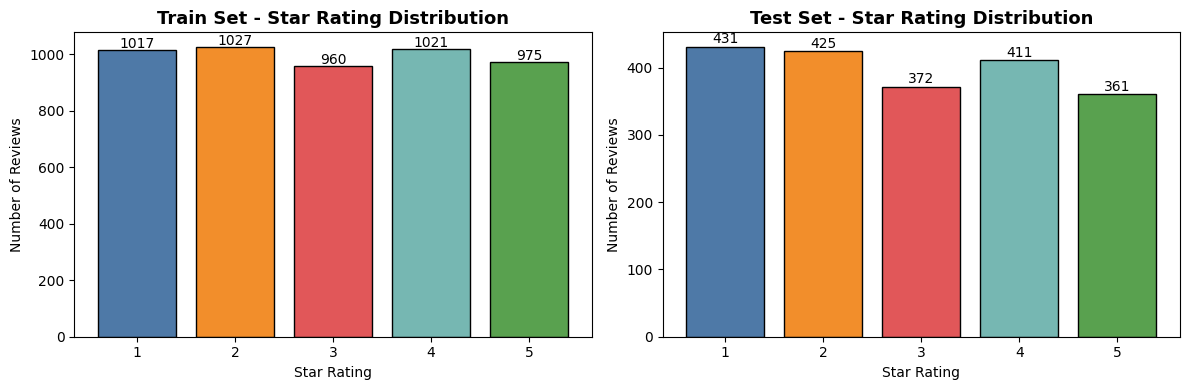

Class distribution plot saved as yelp_distribution.png


In [6]:
# Section 2.4 - Visualize Class Distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']

train_counts = train_df['stars'].value_counts().sort_index()
axes[0].bar(train_counts.index, train_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Train Set - Star Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(train_counts.values):
    axes[0].text(i + 1, v + 5, str(v), ha='center', fontsize=10)

test_counts = test_df['stars'].value_counts().sort_index()
axes[1].bar(test_counts.index, test_counts.values, color=colors, edgecolor='black')
axes[1].set_title('Test Set - Star Rating Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Number of Reviews')
for i, v in enumerate(test_counts.values):
    axes[1].text(i + 1, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('yelp_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Class distribution plot saved as yelp_distribution.png')

### 2.5 Tokenize Dataset for BERT

The BERT tokenizer converts raw text into numerical token IDs and attention masks. Truncation is applied at 128 tokens to reduce memory usage while retaining the most informative portion of each review.

In [7]:
# Section 2.5 - Tokenize Dataset for BERT

BERT_MODEL_NAME = 'bert-base-uncased'
bert_tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

def tokenize_function(examples, tokenizer):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

print('Tokenizing dataset for BERT...')
bert_train = train_dataset.map(lambda x: tokenize_function(x, bert_tokenizer), batched=True)
bert_test  = test_dataset.map(lambda x: tokenize_function(x, bert_tokenizer), batched=True)

bert_train.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
bert_test.set_format(type='torch',  columns=['input_ids', 'attention_mask', 'label'])

print('BERT tokenization complete.')
print('Train shape:', bert_train.shape)
print('Test shape :', bert_test.shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing dataset for BERT...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

BERT tokenization complete.
Train shape: (5000, 5)
Test shape : (2000, 5)


### 2.6 Tokenize Dataset for RoBERTa

RoBERTa uses its own tokenizer which must match the model name exactly. The same tokenization settings are applied for consistency across both models.

In [8]:
# Section 2.6 - Tokenize Dataset for RoBERTa

ROBERTA_MODEL_NAME = 'roberta-base'
roberta_tokenizer  = AutoTokenizer.from_pretrained(ROBERTA_MODEL_NAME)

print('Tokenizing dataset for RoBERTa...')
roberta_train = train_dataset.map(lambda x: tokenize_function(x, roberta_tokenizer), batched=True)
roberta_test  = test_dataset.map(lambda x: tokenize_function(x, roberta_tokenizer), batched=True)

roberta_train.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
roberta_test.set_format(type='torch',  columns=['input_ids', 'attention_mask', 'label'])

print('RoBERTa tokenization complete.')
print('Train shape:', roberta_train.shape)
print('Test shape :', roberta_test.shape)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing dataset for RoBERTa...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

RoBERTa tokenization complete.
Train shape: (5000, 4)
Test shape : (2000, 4)


### 2.7 Define Classification Evaluation Metrics

The following metrics are used to evaluate classification.

- Accuracy: proportion of correctly classified samples
- Precision: proportion of positive predictions that are correct
- Recall: proportion of actual positives that are correctly identified
- F1 Score: harmonic mean of precision and recall

Weighted averaging is used to account for class imbalance across the five star ratings.

In [9]:
# Section 2.7 - Define Classification Evaluation Metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy  = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='weighted', zero_division=0)
    recall    = recall_score(labels, predictions, average='weighted', zero_division=0)
    f1        = f1_score(labels, predictions, average='weighted', zero_division=0)

    print('  Accuracy  :', round(accuracy,  4))
    print('  Precision :', round(precision, 4))
    print('  Recall    :', round(recall,    4))
    print('  F1 Score  :', round(f1,        4))

    return {
        'accuracy' : accuracy,
        'precision': precision,
        'recall'   : recall,
        'f1'       : f1
    }

print('Classification metrics function defined.')

Classification metrics function defined.


### 2.8 Train BERT for Yelp Classification

BERT (Bidirectional Encoder Representations from Transformers) is loaded with a sequence classification head for 5-class prediction. The model is fine-tuned on the Yelp training set using the HuggingFace Trainer.

In [10]:
# Section 2.8 - Train BERT for Yelp Classification

print('Loading BERT model for sequence classification...')
bert_model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=5
)

bert_training_args = TrainingArguments(
    output_dir='./bert_results',
    eval_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to='none',
    save_strategy='no',
    fp16=True
)

bert_trainer = Trainer(
    model=bert_model,
    args=bert_training_args,
    train_dataset=bert_train,
    eval_dataset=bert_test,
    compute_metrics=compute_metrics
)

print('Training BERT...')
bert_trainer.train()
print('BERT training complete.')

Loading BERT model for sequence classification...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training BERT...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,1.019944,0.557000,0.552558,0.557000,0.540991
2,1.106100,1.010111,0.567500,0.568869,0.567500,0.567560
3,1.106100,1.032376,0.575500,0.575544,0.575500,0.575058


  Accuracy  : 0.557
  Precision : 0.5526
  Recall    : 0.557
  F1 Score  : 0.541
  Accuracy  : 0.5675
  Precision : 0.5689
  Recall    : 0.5675
  F1 Score  : 0.5676
  Accuracy  : 0.5755
  Precision : 0.5755
  Recall    : 0.5755
  F1 Score  : 0.5751
BERT training complete.


### 2.9 Evaluate BERT on Test Set

In [11]:
# Section 2.9 - Evaluate BERT on Test Set

print('Evaluating BERT on test set...')
bert_results = bert_trainer.evaluate(eval_dataset=bert_test)

print('BERT Final Results:')
print('  Accuracy  :', round(bert_results['eval_accuracy'],  4))
print('  Precision :', round(bert_results['eval_precision'], 4))
print('  Recall    :', round(bert_results['eval_recall'],    4))
print('  F1 Score  :', round(bert_results['eval_f1'],        4))

Evaluating BERT on test set...


  Accuracy  : 0.5755
  Precision : 0.5755
  Recall    : 0.5755
  F1 Score  : 0.5751
BERT Final Results:
  Accuracy  : 0.5755
  Precision : 0.5755
  Recall    : 0.5755
  F1 Score  : 0.5751


### 2.10 Train RoBERTa for Yelp Classification

RoBERTa (Robustly Optimized BERT Pretraining Approach) is loaded with a classification head for 5-class prediction. RoBERTa improves on BERT by using dynamic masking and training on more data without the next sentence prediction objective.

In [12]:
# Section 2.10 - Train RoBERTa for Yelp Classification

print('Loading RoBERTa model for sequence classification...')
roberta_model = AutoModelForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=5
)

roberta_training_args = TrainingArguments(
    output_dir='./roberta_results',
    eval_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    report_to='none',
    save_strategy='no',
    fp16=True
)

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    train_dataset=roberta_train,
    eval_dataset=roberta_test,
    compute_metrics=compute_metrics
)

print('Training RoBERTa...')
roberta_trainer.train()
print('RoBERTa training complete.')

Loading RoBERTa model for sequence classification...


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training RoBERTa...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.950571,0.577500,0.594926,0.577500,0.574597
2,1.034300,0.923432,0.592500,0.588100,0.592500,0.589237
3,1.034300,0.970662,0.592500,0.591067,0.592500,0.591182


  Accuracy  : 0.5775
  Precision : 0.5949
  Recall    : 0.5775
  F1 Score  : 0.5746
  Accuracy  : 0.5925
  Precision : 0.5881
  Recall    : 0.5925
  F1 Score  : 0.5892
  Accuracy  : 0.5925
  Precision : 0.5911
  Recall    : 0.5925
  F1 Score  : 0.5912
RoBERTa training complete.


### 2.11 Evaluate RoBERTa on Test Set

In [13]:
# Section 2.11 - Evaluate RoBERTa on Test Set

print('Evaluating RoBERTa on test set...')
roberta_results = roberta_trainer.evaluate(eval_dataset=roberta_test)

print('RoBERTa Final Results:')
print('  Accuracy  :', round(roberta_results['eval_accuracy'],  4))
print('  Precision :', round(roberta_results['eval_precision'], 4))
print('  Recall    :', round(roberta_results['eval_recall'],    4))
print('  F1 Score  :', round(roberta_results['eval_f1'],        4))

Evaluating RoBERTa on test set...


  Accuracy  : 0.5925
  Precision : 0.5911
  Recall    : 0.5925
  F1 Score  : 0.5912
RoBERTa Final Results:
  Accuracy  : 0.5925
  Precision : 0.5911
  Recall    : 0.5925
  F1 Score  : 0.5912


### 2.12 Compare BERT vs RoBERTa - Results Table and Chart

Task 1 - Classification Results: BERT vs RoBERTa
------------------------------------------------------------
  Model  Accuracy  Precision  Recall  F1 Score
   BERT    0.5755     0.5755  0.5755    0.5751
RoBERTa    0.5925     0.5911  0.5925    0.5912


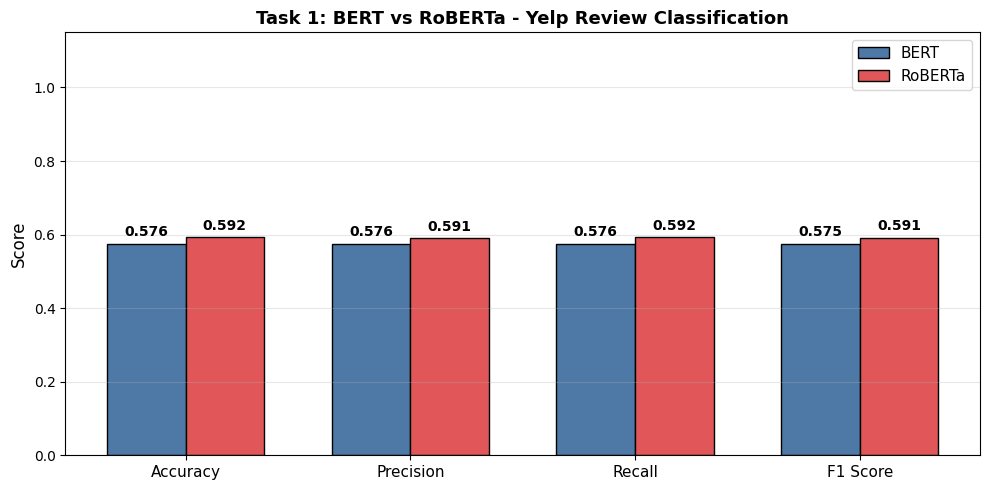

Chart saved as chart1_classification.png


In [14]:
# Section 2.12 - Compare BERT vs RoBERTa Results

classification_df = pd.DataFrame({
    'Model'    : ['BERT', 'RoBERTa'],
    'Accuracy' : [round(bert_results['eval_accuracy'],   4), round(roberta_results['eval_accuracy'],  4)],
    'Precision': [round(bert_results['eval_precision'],  4), round(roberta_results['eval_precision'], 4)],
    'Recall'   : [round(bert_results['eval_recall'],     4), round(roberta_results['eval_recall'],    4)],
    'F1 Score' : [round(bert_results['eval_f1'],         4), round(roberta_results['eval_f1'],        4)]
})

print('Task 1 - Classification Results: BERT vs RoBERTa')
print('-' * 60)
print(classification_df.to_string(index=False))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
bert_scores    = [bert_results['eval_accuracy'],    bert_results['eval_precision'],
                  bert_results['eval_recall'],       bert_results['eval_f1']]
roberta_scores = [roberta_results['eval_accuracy'], roberta_results['eval_precision'],
                  roberta_results['eval_recall'],    roberta_results['eval_f1']]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, bert_scores,    width, label='BERT',    color='#4e79a7', edgecolor='black')
bars2 = ax.bar(x + width/2, roberta_scores, width, label='RoBERTa', color='#e15759', edgecolor='black')
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Task 1: BERT vs RoBERTa - Yelp Review Classification', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            str(round(bar.get_height(), 3)), ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            str(round(bar.get_height(), 3)), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_classification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as chart1_classification.png')

### 2.13 Confusion Matrix - BERT and RoBERTa

Confusion matrices show the distribution of predictions across all five star rating classes. They help identify which classes are most frequently confused with one another, providing insight into model bias and error patterns.

  Accuracy  : 0.5755
  Precision : 0.5755
  Recall    : 0.5755
  F1 Score  : 0.5751


  Accuracy  : 0.5925
  Precision : 0.5911
  Recall    : 0.5925
  F1 Score  : 0.5912


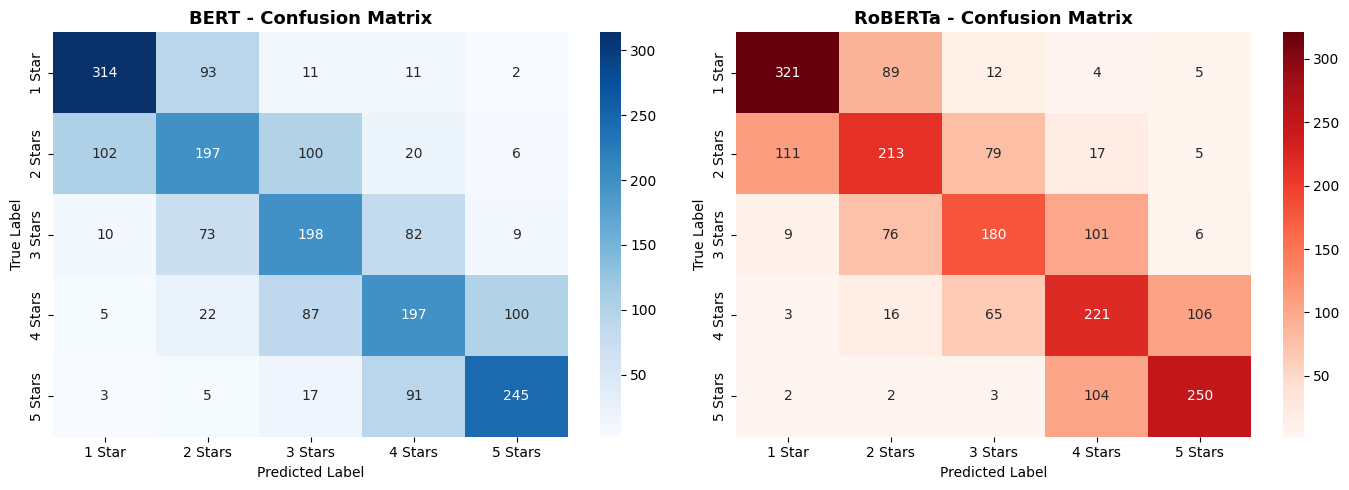

Confusion matrix saved as chart2_confusion_matrix.png


In [15]:
# Section 2.13 - Confusion Matrix for BERT and RoBERTa

bert_preds          = bert_trainer.predict(bert_test)
roberta_preds       = roberta_trainer.predict(roberta_test)

bert_pred_labels    = np.argmax(bert_preds.predictions,    axis=-1)
roberta_pred_labels = np.argmax(roberta_preds.predictions, axis=-1)
true_labels         = bert_preds.label_ids

bert_cm    = confusion_matrix(true_labels, bert_pred_labels)
roberta_cm = confusion_matrix(true_labels, roberta_pred_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(bert_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['1 Star','2 Stars','3 Stars','4 Stars','5 Stars'],
            yticklabels=['1 Star','2 Stars','3 Stars','4 Stars','5 Stars'])
axes[0].set_title('BERT - Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(roberta_cm, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['1 Star','2 Stars','3 Stars','4 Stars','5 Stars'],
            yticklabels=['1 Star','2 Stars','3 Stars','4 Stars','5 Stars'])
axes[1].set_title('RoBERTa - Confusion Matrix', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('chart2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved as chart2_confusion_matrix.png')

---
## Section 3: Task 2 - Text Summarisation
### 3.1 Load the CNN/DailyMail Dataset

The CNN/DailyMail dataset is loaded from HuggingFace. It contains news articles paired with human-written highlights used as reference summaries. This dataset is used to evaluate T5-small and BART-large-cnn on abstractive summarisation.

In [16]:
# Section 3.1 - Load the CNN/DailyMail Dataset

print('Loading CNN/DailyMail dataset from HuggingFace...')
cnn_dataset = load_dataset('abisee/cnn_dailymail', '3.0.0')

print('Dataset loaded.')
print('Train size      :', len(cnn_dataset['train']), 'samples')
print('Validation size :', len(cnn_dataset['validation']), 'samples')
print('Test size       :', len(cnn_dataset['test']), 'samples')
print('Features        :', cnn_dataset['train'].features)

Loading CNN/DailyMail dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

Dataset loaded.
Train size      : 287113 samples
Validation size : 13368 samples
Test size       : 11490 samples
Features        : {'article': Value('string'), 'highlights': Value('string'), 'id': Value('string')}


### 3.2 Explore the CNN/DailyMail Dataset

In [17]:
# Section 3.2 - Explore the CNN/DailyMail Dataset

sample = cnn_dataset['train'][0]
print('Sample Article (first 300 characters)')
print('-' * 60)
print(sample['article'][:300])
print()
print('Sample Reference Summary')
print('-' * 60)
print(sample['highlights'])
print()
print('Article word count :', len(sample['article'].split()))
print('Summary word count :', len(sample['highlights'].split()))

Sample Article (first 300 characters)
------------------------------------------------------------
LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappoi

Sample Reference Summary
------------------------------------------------------------
Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .

Article word count : 455
Summary word count : 41


### 3.3 Downsample the CNN/DailyMail Dataset

The dataset is downsampled to reduce training time on limited GPU resources.

In [18]:
# Section 3.3 - Downsample the CNN/DailyMail Dataset

TRAIN_SAMPLES = 2000
TEST_SAMPLES  = 500

cnn_train = cnn_dataset['train'].shuffle(seed=42).select(range(TRAIN_SAMPLES))
cnn_test  = cnn_dataset['test'].shuffle(seed=42).select(range(TEST_SAMPLES))

print('Downsampling complete.')
print('Train samples :', len(cnn_train))
print('Test samples  :', len(cnn_test))
print('Columns       :', cnn_train.column_names)

Downsampling complete.
Train samples : 2000
Test samples  : 500
Columns       : ['article', 'highlights', 'id']


### 3.4 Visualise Article and Summary Length Distribution

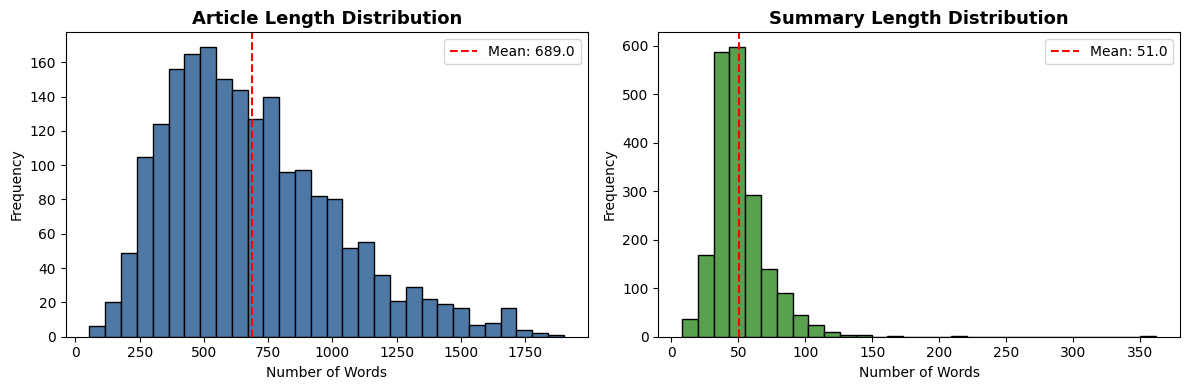

Length distribution saved as cnn_length_distribution.png


In [19]:
# Section 3.4 - Visualise Article and Summary Length Distribution

cnn_df = pd.DataFrame(cnn_train)
cnn_df['article_len'] = cnn_df['article'].apply(lambda x: len(x.split()))
cnn_df['summary_len'] = cnn_df['highlights'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(cnn_df['article_len'], bins=30, color='#4e79a7', edgecolor='black')
axes[0].set_title('Article Length Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].axvline(cnn_df['article_len'].mean(), color='red', linestyle='--',
                label='Mean: ' + str(round(cnn_df['article_len'].mean(), 0)))
axes[0].legend()

axes[1].hist(cnn_df['summary_len'], bins=30, color='#59a14f', edgecolor='black')
axes[1].set_title('Summary Length Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].axvline(cnn_df['summary_len'].mean(), color='red', linestyle='--',
                label='Mean: ' + str(round(cnn_df['summary_len'].mean(), 0)))
axes[1].legend()

plt.tight_layout()
plt.savefig('cnn_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Length distribution saved as cnn_length_distribution.png')

### 3.5 Tokenize Dataset for T5

In [22]:
# Section 3.5 - Tokenize Dataset for T5

T5_MODEL_NAME = 't5-small'
t5_tokenizer  = AutoTokenizer.from_pretrained(T5_MODEL_NAME)
t5_tokenizer.add_special_tokens({'pad_token': t5_tokenizer.eos_token})

def preprocess_t5(examples, tokenizer):
    prefix = 'summarize: '
    inputs = [prefix + article for article in examples['article']]
    max_len = min(tokenizer.model_max_length, 512)
    model_inputs = tokenizer(inputs, max_length=max_len, truncation=True, padding='max_length')
    labels = tokenizer(text_target=examples['highlights'], max_length=128, truncation=True, padding='max_length')
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

print('Tokenizing dataset for T5...')
t5_train = cnn_train.map(partial(preprocess_t5, tokenizer=t5_tokenizer), batched=True, remove_columns=cnn_train.column_names)
t5_test  = cnn_test.map(partial(preprocess_t5, tokenizer=t5_tokenizer), batched=True, remove_columns=cnn_test.column_names)

print('T5 tokenization complete.')
print('Train shape:', t5_train.shape)
print('Test shape :', t5_test.shape)

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing dataset for T5...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

T5 tokenization complete.
Train shape: (2000, 3)
Test shape : (500, 3)


### 3.6 Tokenize Dataset for BART

BART uses its own tokenizer and does not require a task prefix. It is pretrained as a denoising autoencoder and fine-tuned on CNN/DailyMail for summarisation.

In [23]:
# Section 3.6 - Tokenize Dataset for BART

BART_MODEL_NAME = 'facebook/bart-large-cnn'
bart_tokenizer  = AutoTokenizer.from_pretrained(BART_MODEL_NAME)

def preprocess_bart(examples, tokenizer):
    model_inputs = tokenizer(examples['article'], max_length=512, truncation=True, padding='max_length')
    labels = tokenizer(text_target=examples['highlights'], max_length=128, truncation=True, padding='max_length')
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

print('Tokenizing dataset for BART...')
bart_train = cnn_train.map(partial(preprocess_bart, tokenizer=bart_tokenizer), batched=True, remove_columns=cnn_train.column_names)
bart_test  = cnn_test.map(partial(preprocess_bart, tokenizer=bart_tokenizer), batched=True, remove_columns=cnn_test.column_names)

print('BART tokenization complete.')
print('Train shape:', bart_train.shape)
print('Test shape :', bart_test.shape)

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing dataset for BART...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

BART tokenization complete.
Train shape: (2000, 3)
Test shape : (500, 3)


### 3.7 Define Summarisation Evaluation Metrics

The following metrics are used to evaluate summarisation performance:
- ROUGE-1: overlap of unigrams between generated and reference summaries
- ROUGE-2: overlap of bigrams between generated and reference summaries
- ROUGE-L: longest common subsequence between generated and reference summaries
- BLEU-1, BLEU-2, BLEU-4: precision of n-gram matches between generated and reference summaries

In [24]:
# Section 3.7 - Define Summarisation Evaluation Metrics

rouge_metric = evaluate.load('rouge')
bleu_metric  = evaluate.load('bleu')

def compute_summarisation_metrics(eval_pred, tokenizer):
    predictions, labels = eval_pred

    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
    labels      = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds  = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds  = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    rouge_result = rouge_metric.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

    try:
        bleu_1 = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels, max_order=1)['bleu']
    except:
        bleu_1 = 0
    try:
        bleu_2 = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels, max_order=2)['bleu']
    except:
        bleu_2 = 0
    try:
        bleu_4 = bleu_metric.compute(predictions=decoded_preds, references=decoded_labels, max_order=4)['bleu']
    except:
        bleu_4 = 0

    outputs = {k: round(v, 4) for k, v in rouge_result.items()}
    outputs.update({'bleu_1': round(bleu_1, 4), 'bleu_2': round(bleu_2, 4), 'bleu_4': round(bleu_4, 4)})

    print('  ROUGE-1 :', outputs['rouge1'])
    print('  ROUGE-2 :', outputs['rouge2'])
    print('  ROUGE-L :', outputs['rougeL'])
    print('  BLEU-1  :', outputs['bleu_1'])
    print('  BLEU-2  :', outputs['bleu_2'])
    print('  BLEU-4  :', outputs['bleu_4'])

    return outputs

print('Summarisation metrics function defined.')

Summarisation metrics function defined.


### 3.8 Train T5-small for Summarisation

T5-small is an encoder-decoder model fine-tuned on the CNN/DailyMail training set.

In [27]:
# Section 3.8 - Train T5-small for Summarisation

print('Loading T5-small model...')
t5_model = AutoModelForSeq2SeqLM.from_pretrained('t5-small')

t5_data_collator = DataCollatorForSeq2Seq(tokenizer=t5_tokenizer, model=t5_model)

t5_training_args = Seq2SeqTrainingArguments(
    output_dir='./t5_results',
    eval_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy='no',
    report_to='none',
    predict_with_generate=True,
    generation_max_length=128,
    fp16=True
)

t5_trainer = Seq2SeqTrainer(
    model=t5_model,
    args=t5_training_args,
    train_dataset=t5_train,
    eval_dataset=t5_test,
    tokenizer=t5_tokenizer,
    data_collator=t5_data_collator,
    compute_metrics=partial(compute_summarisation_metrics, tokenizer=t5_tokenizer)
)

print('Training T5-small...')
t5_trainer.train()
print('T5-small training complete.')

Loading T5-small model...
Training T5-small...


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Bleu 1,Bleu 2,Bleu 4
1,No log,1.222768,0.402200,0.177700,0.285900,0.286000,0.392100,0.257900,0.147900


  ROUGE-1 : 0.4022
  ROUGE-2 : 0.1777
  ROUGE-L : 0.2859
  BLEU-1  : 0.3921
  BLEU-2  : 0.2579
  BLEU-4  : 0.1479


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Bleu 1,Bleu 2,Bleu 4
1,No log,1.222768,0.402200,0.177700,0.285900,0.286000,0.392100,0.257900,0.147900
2,1.292800,1.200075,0.402900,0.177700,0.283500,0.283800,0.391700,0.259100,0.148800
3,1.292800,1.197375,0.404100,0.177300,0.282800,0.283000,0.394800,0.260400,0.148400


  ROUGE-1 : 0.4029
  ROUGE-2 : 0.1777
  ROUGE-L : 0.2835
  BLEU-1  : 0.3917
  BLEU-2  : 0.2591
  BLEU-4  : 0.1488
  ROUGE-1 : 0.4041
  ROUGE-2 : 0.1773
  ROUGE-L : 0.2828
  BLEU-1  : 0.3948
  BLEU-2  : 0.2604
  BLEU-4  : 0.1484
T5-small training complete.


### 3.9 Evaluate T5-small on Test Set

In [ ]:
# Section 3.9 - Evaluate T5-small on Test Set

print('Evaluating T5-small on test set...')
t5_results = t5_trainer.evaluate(eval_dataset=t5_test)

print('T5-small Final Results:')
print('  ROUGE-1 :', round(t5_results['eval_rouge1'],  4))
print('  ROUGE-2 :', round(t5_results['eval_rouge2'],  4))
print('  ROUGE-L :', round(t5_results['eval_rougeL'],  4))
print('  BLEU-1  :', round(t5_results['eval_bleu_1'],  4))
print('  BLEU-2  :', round(t5_results['eval_bleu_2'],  4))
print('  BLEU-4  :', round(t5_results['eval_bleu_4'],  4))

Evaluating T5-small on test set...


### 3.10 Evaluate BART-large-cnn on Test Set

BART-large-cnn is already fine-tuned on the CNN/DailyMail dataset, so zero-shot evaluation is performed without additional training. This allows a direct comparison with T5-small which was fine-tuned from scratch.

In [29]:
# Section 3.10 - Evaluate BART-large-cnn on Test Set

print('Loading BART-large-cnn model...')
bart_model = AutoModelForSeq2SeqLM.from_pretrained('facebook/bart-large-cnn')

bart_data_collator = DataCollatorForSeq2Seq(tokenizer=bart_tokenizer, model=bart_model)

bart_training_args = Seq2SeqTrainingArguments(
    output_dir='./bart_results',
    eval_strategy='epoch',
    per_device_eval_batch_size=4,
    per_device_train_batch_size=4,
    num_train_epochs=1,
    predict_with_generate=True,
    generation_max_length=128,
    report_to='none',
    save_strategy='no',
    fp16=True
)

bart_trainer = Seq2SeqTrainer(
    model=bart_model,
    args=bart_training_args,
    train_dataset=bart_train,
    eval_dataset=bart_test,
    tokenizer=bart_tokenizer,
    data_collator=bart_data_collator,
    compute_metrics=partial(compute_summarisation_metrics, tokenizer=bart_tokenizer)
)

print('Evaluating BART-large-cnn on test set...')
bart_results = bart_trainer.evaluate(eval_dataset=bart_test)

print('BART-large-cnn Final Results:')
print('  ROUGE-1 :', round(bart_results['eval_rouge1'],  4))
print('  ROUGE-2 :', round(bart_results['eval_rouge2'],  4))
print('  ROUGE-L :', round(bart_results['eval_rougeL'],  4))
print('  BLEU-1  :', round(bart_results['eval_bleu_1'],  4))
print('  BLEU-2  :', round(bart_results['eval_bleu_2'],  4))
print('  BLEU-4  :', round(bart_results['eval_bleu_4'],  4))

Loading BART-large-cnn model...


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Evaluating BART-large-cnn on test set...


  ROUGE-1 : 0.4326
  ROUGE-2 : 0.2052
  ROUGE-L : 0.3007
  BLEU-1  : 0.4077
  BLEU-2  : 0.278
  BLEU-4  : 0.1667
BART-large-cnn Final Results:
  ROUGE-1 : 0.4326
  ROUGE-2 : 0.2052
  ROUGE-L : 0.3007
  BLEU-1  : 0.4077
  BLEU-2  : 0.278
  BLEU-4  : 0.1667


### 3.11 Compare T5 vs BART - Results Table and Chart

Task 2 - Summarisation Results: T5-small vs BART-large-cnn
------------------------------------------------------------
         Model  ROUGE-1  ROUGE-2  ROUGE-L  BLEU-1  BLEU-2  BLEU-4
      T5-small   0.4041   0.1773   0.2828  0.3948  0.2604  0.1484
BART-large-cnn   0.4326   0.2052   0.3007  0.4077  0.2780  0.1667


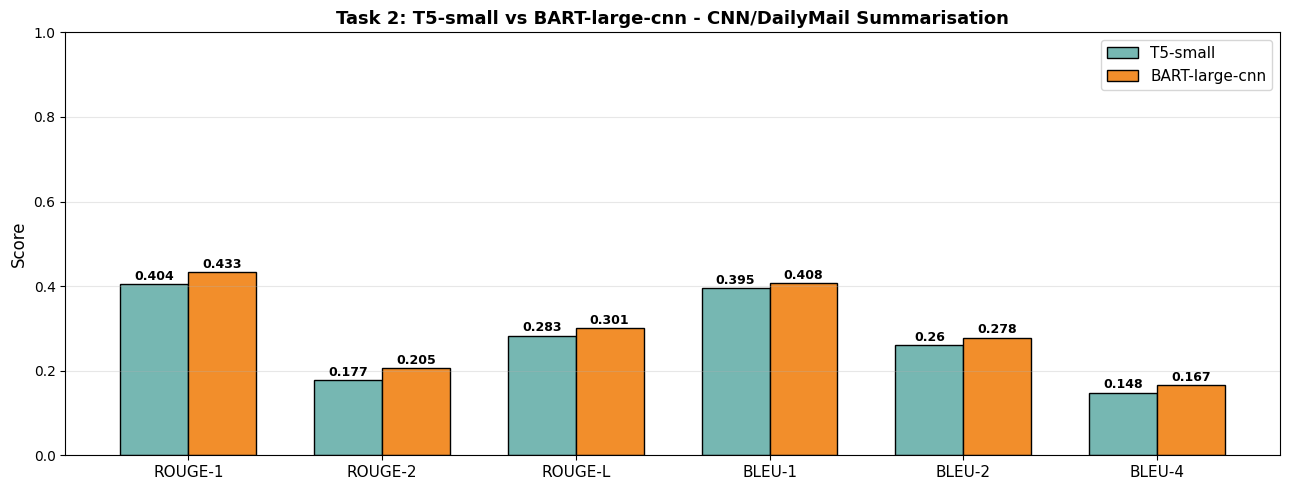

Chart saved as chart3_summarisation.png


In [30]:
# Section 3.11 - Compare T5 vs BART Results

summarisation_df = pd.DataFrame({
    'Model'  : ['T5-small', 'BART-large-cnn'],
    'ROUGE-1': [round(t5_results['eval_rouge1'],  4), round(bart_results['eval_rouge1'],  4)],
    'ROUGE-2': [round(t5_results['eval_rouge2'],  4), round(bart_results['eval_rouge2'],  4)],
    'ROUGE-L': [round(t5_results['eval_rougeL'],  4), round(bart_results['eval_rougeL'],  4)],
    'BLEU-1' : [round(t5_results['eval_bleu_1'],  4), round(bart_results['eval_bleu_1'],  4)],
    'BLEU-2' : [round(t5_results['eval_bleu_2'],  4), round(bart_results['eval_bleu_2'],  4)],
    'BLEU-4' : [round(t5_results['eval_bleu_4'],  4), round(bart_results['eval_bleu_4'],  4)],
})

print('Task 2 - Summarisation Results: T5-small vs BART-large-cnn')
print('-' * 60)
print(summarisation_df.to_string(index=False))

metrics_summ = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU-1', 'BLEU-2', 'BLEU-4']
t5_scores    = [t5_results['eval_rouge1'],   t5_results['eval_rouge2'],
                t5_results['eval_rougeL'],   t5_results['eval_bleu_1'],
                t5_results['eval_bleu_2'],   t5_results['eval_bleu_4']]
bart_scores  = [bart_results['eval_rouge1'], bart_results['eval_rouge2'],
                bart_results['eval_rougeL'], bart_results['eval_bleu_1'],
                bart_results['eval_bleu_2'], bart_results['eval_bleu_4']]

x     = np.arange(len(metrics_summ))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, t5_scores,   width, label='T5-small',      color='#76b7b2', edgecolor='black')
bars2 = ax.bar(x + width/2, bart_scores, width, label='BART-large-cnn', color='#f28e2b', edgecolor='black')
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Task 2: T5-small vs BART-large-cnn - CNN/DailyMail Summarisation', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_summ, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            str(round(bar.get_height(), 3)), ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            str(round(bar.get_height(), 3)), ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_summarisation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as chart3_summarisation.png')

### 3.12 Qualitative Analysis - Sample Generated Summaries

Three sample summaries are generated from each model and compared against the reference summaries. This qualitative analysis provides insight into the fluency, factual accuracy, and abstractiveness of each model's output.

In [31]:
# Section 3.12 - Qualitative Analysis: Sample Generated Summaries

print('Qualitative Analysis - Sample Generated Summaries')
print('=' * 70)

for i in range(3):
    sample_article = cnn_test[i]['article'][:512]
    reference      = cnn_test[i]['highlights']

    t5_input   = t5_tokenizer('summarize: ' + sample_article, return_tensors='pt',
                               max_length=512, truncation=True).input_ids.to(t5_trainer.args.device)
    t5_out     = t5_model.generate(t5_input, max_new_tokens=80, do_sample=False)
    t5_summary = t5_tokenizer.decode(t5_out[0], skip_special_tokens=True)

    bart_input   = bart_tokenizer(sample_article, return_tensors='pt',
                                   max_length=512, truncation=True).input_ids.to(bart_trainer.args.device)
    bart_out     = bart_model.generate(bart_input, max_new_tokens=80, do_sample=False)
    bart_summary = bart_tokenizer.decode(bart_out[0], skip_special_tokens=True)

    print()
    print('Example', i + 1)
    print('-' * 70)
    print('Article   :', sample_article[:200], '...')
    print('Reference :', reference)
    print('T5        :', t5_summary)
    print('BART      :', bart_summary)

print()
print('Qualitative analysis complete.')

Qualitative Analysis - Sample Generated Summaries

Example 1
----------------------------------------------------------------------
Article   : (CNN) I see signs of a revolution everywhere. I see it in the op-ed pages of the newspapers, and on the state ballots in nearly half the country. I see it in politicians who once preferred to play it  ...
Reference : CNN's Dr. Sanjay Gupta says we should legalize medical marijuana now .
He says he knows how easy it is do nothing "because I did nothing for too long"
T5        : I see the revolution everywhere in the eyes of sterling scientists. I see it in the eyes of scientists who are diving in head first.
BART      : I see signs of a revolution everywhere. I see it in the op-ed pages of the newspapers, and on the state ballots in nearly half the country. Politicians who once preferred to play it safe with this explosive issue are now willing to stake their political futures on it. Scientists, previously reluctant to dip a toe into this heavil

---
## Section 4: Final Results Summary
### 4.1 Combined Results Table and Export

In [32]:
# Section 4.1 - Combined Results Table and Export

print('=' * 70)
print('COMP6012 Assignment 2 - Final Results Summary')
print('=' * 70)

print()
print('Task 1 - Text Classification on Yelp Review Full Dataset')
print('-' * 70)
print(classification_df.to_string(index=False))

print()
print('Task 2 - Text Summarisation on CNN/DailyMail Dataset')
print('-' * 70)
print(summarisation_df.to_string(index=False))

classification_df.to_csv('task1_classification_results.csv', index=False)
summarisation_df.to_csv('task2_summarisation_results.csv',   index=False)

print()
print('Files saved:')
print('  task1_classification_results.csv')
print('  task2_summarisation_results.csv')
print('  chart1_classification.png')
print('  chart2_confusion_matrix.png')
print('  chart3_summarisation.png')
print('  yelp_distribution.png')
print('  cnn_length_distribution.png')

COMP6012 Assignment 2 - Final Results Summary

Task 1 - Text Classification on Yelp Review Full Dataset
----------------------------------------------------------------------
  Model  Accuracy  Precision  Recall  F1 Score
   BERT    0.5755     0.5755  0.5755    0.5751
RoBERTa    0.5925     0.5911  0.5925    0.5912

Task 2 - Text Summarisation on CNN/DailyMail Dataset
----------------------------------------------------------------------
         Model  ROUGE-1  ROUGE-2  ROUGE-L  BLEU-1  BLEU-2  BLEU-4
      T5-small   0.4041   0.1773   0.2828  0.3948  0.2604  0.1484
BART-large-cnn   0.4326   0.2052   0.3007  0.4077  0.2780  0.1667

Files saved:
  task1_classification_results.csv
  task2_summarisation_results.csv
  chart1_classification.png
  chart2_confusion_matrix.png
  chart3_summarisation.png
  yelp_distribution.png
  cnn_length_distribution.png
